# 📚 Pipeline de Treinamento e Avaliação de Modelos

**Projeto:** Análise e Predição de Alarmes (`Is_Dont_Go`)  
**Fase:** Modelagem Preditiva e Validação Estatística

Este notebook realiza a partição dos dados preparados em conjuntos de treino e teste, o treinamento do classificador de Regressão Logística com balanceamento de pesos e a avaliação rigorosa do desempenho através de matrizes de confusão, métricas vetoriais e análise de interpretabilidade dos coeficientes.

## 🔍 1. Importação dos Dados Preparados

Nesta etapa inicial, carregamos a matriz de atributos numéricos (`dados_preparados.csv`) gerada ao final da etapa de Engenharia de Atributos (Notebook 2), isolando novamente a variável alvo binária `Is_Dont_Go` das variáveis preditoras (features).

In [1]:
import pandas as pd

# Lê o arquivo que foi criado pelo Notebook 2
df_import = pd.read_csv('dados_preparados.csv')

# Recria as variáveis X e y esperadas pelo resto do notebook
X = df_import.drop(columns=['Is_Dont_Go'])
y = df_import['Is_Dont_Go']

print("Dados carregados com sucesso!")

Dados carregados com sucesso!


## 🔍 2. Divisão Estocástica e Estratificação (Treino / Teste)

Para garantir uma validação justa do modelo, dividimos a base de dados em **70% para treinamento** e **30% para teste**. 
> 💡 **Nota:** Como a variável alvo `Is_Dont_Go` é altamente desbalanceada (poucos eventos impeditivos em relação ao total), aplicamos o parâmetro `stratify=y` para assegurar que a mesma proporção de classes seja mantida rigorosamente em ambos os conjuntos de dados.

In [2]:
from sklearn.model_selection import train_test_split

# Dividindo 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 4320001 amostras
Tamanho do Teste: 1080001 amostras


## 🔍 3. Otimização e Treinamento do Modelo

Utilizamos o estimador de **Regressão Logística** configurado com `class_weight='balanced'`. Essa técnica ajusta os pesos da função de perda inversamente proporcionais às frequências das classes na base de treino, penalizando mais severamente os erros cometidos na classe minoritária (alarmes reais que impedem a operação).

In [7]:
from sklearn.linear_model import LogisticRegression

# Instanciando o modelo
# max_iter foi aumentado para garantir que o algoritmo convirja sem avisos de erro
modelo_lr = LogisticRegression(max_iter=100, random_state=42, class_weight='balanced')

# Treinando o modelo
modelo_lr.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


## 🔍 4. Validação de Desempenho e Métricas de Classificação

### 🛠️ 4.1 Avaliação de Performance do Classificador

Para validar a qualidade das predições, extraímos a matriz de confusão e métricas de desempenho baseadas em erros de Tipo I (Falsos Positivos) e Tipo II (Falsos Negativos):
* **Precisão (Precision):** Proporção de alarmes classificados como 'Não Vá' que realmente eram impeditivos.
* **Revocação (Recall):** Capacidade do modelo de capturar todos os eventos reais de 'Não Vá' contidos na base.
* **F1-Score:** Média harmônica balanceada entre precisão e revocação.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Geração das predições binárias com base no limiar padrão (threshold = 0.5)
y_pred = modelo_lr.predict(X)


# 2. Cálculo da acurácia global do modelo
acuracia = accuracy_score(y, y_pred)
print(f"Acurácia Global do Modelo: {acuracia:.4f}\n")

# 3. Exibição do relatório completo de classificação estruturado por classe
print("--- Relatório de Classificação Detalhado ---")
print(classification_report(y, y_pred))

# 4. Matriz de Confusão para análise visual de erros de classificação
print("--- Matriz de Confusão Vetorial ---")
print(confusion_matrix(y, y_pred))

Acurácia Global do Modelo: 0.9313

--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   5397421
           1       0.01      0.94      0.01      2581

    accuracy                           0.93   5400002
   macro avg       0.50      0.93      0.49   5400002
weighted avg       1.00      0.93      0.96   5400002

--- Matriz de Confusão Vetorial ---
[[5026776  370645]
 [    167    2414]]


### 🛠️ 4.2 Análise de Sensibilidade e Importância dos Atributos (Coeficientes)

Ao contrário de modelos de caixa-preta, a Regressão Logística possui alta interpretabilidade. O peso (coeficiente) de cada variável indica o logaritmo da razão de chances (*log-odds*). 
* **Coeficientes Positivos:** Aumentam a probabilidade do evento `Is_Dont_Go` ocorrer (fatores de risco).
* **Coeficientes Negativos:** Diminuem a probabilidade do evento ocorrer (efeito inverso ou de proteção).

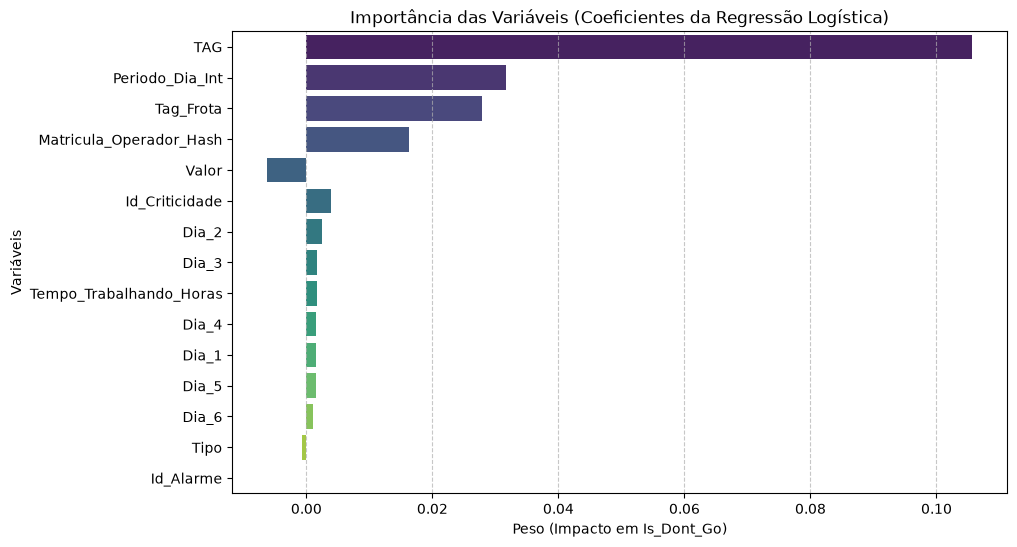

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando um DataFrame com os coeficientes do modelo
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

# Ordenando pelos coeficientes de maior impacto absoluto
importancias['Impacto_Absoluto'] = importancias['Coeficiente'].abs()
importancias = importancias.sort_values(by='Impacto_Absoluto', ascending=False)

# Plotando os coeficientes
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='Coeficiente', y='Variavel', palette='viridis', hue='Variavel')
plt.title('Importância das Variáveis (Coeficientes da Regressão Logística)')
plt.xlabel('Peso (Impacto em Is_Dont_Go)')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
df_import.head()

,TAG,Tag_Frota,Tipo,Matricula_Operador_Hash,Id_Alarme,Id_Criticidade,Valor,Tempo_Trabalhando_Horas,Periodo_Dia_Int,Dia_1,Dia_2,Dia_3,Dia_4,Dia_5,Dia_6,Is_Dont_Go
0,0,3,0,0,335609934,3,-0.158350,0.000883,3,0,1,0,0,0,0,0
1,0,3,0,0,335609935,3,-0.158350,0.000883,3,0,1,0,0,0,0,0
2,0,3,0,0,84626976,3,1.388878,0.011237,3,0,1,0,0,0,0,0
3,0,3,0,0,84626976,3,2.480415,0.014433,3,0,1,0,0,0,0,0
4,0,3,0,0,84626976,3,3.508368,0.017635,3,0,1,0,0,0,0,0
